<a href="https://colab.research.google.com/github/shauryasachdev/Deep-Learning/blob/main/TransferLearningImplementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow==2.19 matplotlib==3.9.1
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
# load the model VGG16 pre-trained on ImageNet
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the base model layers
for layer in base_model.layers:
  layer.trainable=False

# create a new model and add more layers such as Dense and Flatten
model =Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dense(1, activation='sigmoid')
])

# compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [3]:
import os
from PIL import Image
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

# Your folder path (adjust if needed)
folder_path = '/content/drive/MyDrive/Colab Notebooks/MyProjects2'

# create directories if they don't exist
os.makedirs(os.path.join(folder_path,'sample/data_class_a'),exist_ok=True)
os.makedirs(os.path.join(folder_path,'sample/data_class_b'),exist_ok=True)

# create 10 images for each class
for i in range(10):
  # create a blank white image for class_a
  img = Image.fromarray(np.ones((224,224,3), dtype='uint8')*255)
  img.save(os.path.join(folder_path,'sample/data_class_a/',f'img_{i}.jpg'))

  # create blank black image for class_b
  img = Image.fromarray(np.zeros((224,224,3), dtype='uint8'))
  img.save(os.path.join(folder_path,'sample/data_class_b/',f'img_{i}.jpg'))


Mounted at /content/drive


In [4]:
# Load and pre-process the dataset
train_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    os.path.join(folder_path,'sample'),
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

# Verify if the generator has loaded the images correctly
print(f'Found {train_generator.samples} images belonging to {train_generator.num_classes} classes.')

# Train the model
if train_generator.samples > 0:
  model.fit(train_generator, epochs=10)

Found 20 images belonging to 2 classes.
Found 20 images belonging to 2 classes.
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step - accuracy: 0.5000 - loss: 0.7573
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step - accuracy: 0.5000 - loss: 6.1905
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 0.5000 - loss: 2.9145
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 1.0000 - loss: 0.4915
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 0.5000 - loss: 0.7130
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.5000 - loss: 0.7216
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.5000 - loss: 0.7274
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 0.5000 - loss: 0.7299
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 0.5000 - loss: 0.7292
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 0.5000 - loss: 0.7258


In [5]:
# Fine Tune the Model
for layer in base_model.layers[-4:]:
  layer.trainable=True

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(train_generator, epochs=10)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step - accuracy: 0.5000 - loss: 0.7202
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step - accuracy: 0.5000 - loss: 0.6635
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 0.5000 - loss: 1.3014
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 0.5000 - loss: 0.7642
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 0.5000 - loss: 0.6946
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 0.5000 - loss: 0.6402
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step - accuracy: 1.0000 - loss: 0.6132
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 1.0000 - loss: 0.5285
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 1.0000 - loss: 0.4062
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 1.0000 - loss: 0.2641


Found 16 images belonging to 2 classes.
Found 4 images belonging to 2 classes.
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 1.0000 - loss: 7.2275e-18 - val_accuracy: 1.0000 - val_loss: 1.2483e-19
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 1.0000 - loss: 1.2483e-19 - val_accuracy: 1.0000 - val_loss: 2.3700e-21
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 1.0000 - loss: 2.3700e-21 - val_accuracy: 1.0000 - val_loss: 5.1220e-23
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 1.0000 - loss: 5.1220e-23 - val_accuracy: 1.0000 - val_loss: 1.2916e-24
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 1.0000 - loss: 1.2916e-24 - val_accuracy: 1.0000 - val_loss: 3.8214e-26
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 1.0000 - loss: 3.8214e-26 - val_accuracy: 1.0000 - val_loss: 1.3511e-27
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 1.0000 - loss: 1.3511e-27 - val_accuracy: 1.0000 - val_loss: 5.6988e-29
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step - accuracy: 1.0000 - loss: 5.69

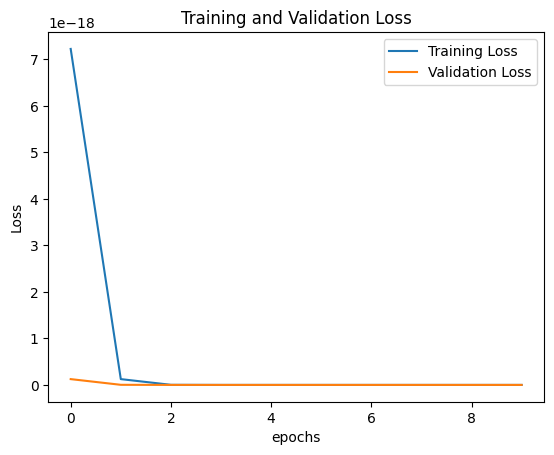

In [8]:
# Modify data generator to include validation split
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    os.path.join(folder_path,'sample'),
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    os.path.join(folder_path,'sample'),
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

history = model.fit(train_generator, epochs=10, validation_data=validation_generator)

# plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step - accuracy: 0.5000 - loss: 0.6929 - val_accuracy: 0.5000 - val_loss: 0.6919
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 0.5000 - loss: 0.6919 - val_accuracy: 0.5000 - val_loss: 0.6913
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 0.5000 - loss: 0.6913 - val_accuracy: 0.5000 - val_loss: 0.6907
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 0.5000 - loss: 0.6907 - val_accuracy: 1.0000 - val_loss: 0.6902
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 1.0000 - loss: 0.6902 - val_accuracy: 1.0000 - val_loss: 0.6899
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 1.0000 - loss: 0.6899 - val_accuracy: 1.0000 - val_loss: 0.6895
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 1.0000 - loss: 0.6895 - val_accuracy: 1.0000 - val_loss: 0.6891
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 1.0000 - loss: 0.6891 - val_accuracy: 1.0000 - val_loss: 0.6888


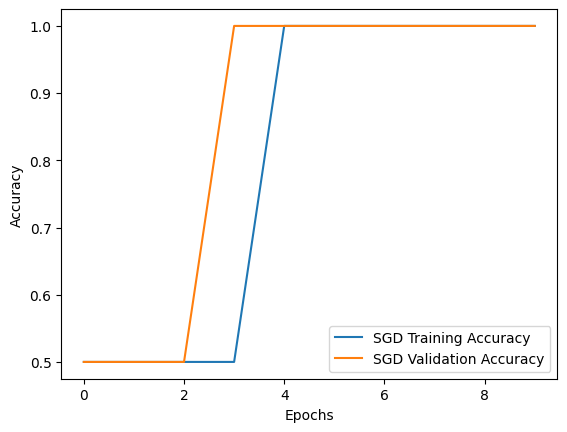

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step - accuracy: 0.5000 - loss: 0.6924 - val_accuracy: 0.5000 - val_loss: 0.6742
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step - accuracy: 0.5000 - loss: 0.6742 - val_accuracy: 0.5000 - val_loss: 0.5161
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step - accuracy: 0.5000 - loss: 0.5161 - val_accuracy: 1.0000 - val_loss: 0.3387
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step - accuracy: 1.0000 - loss: 0.3387 - val_accuracy: 1.0000 - val_loss: 0.3087
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 1.0000 - loss: 0.3087 - val_accuracy: 1.0000 - val_loss: 0.2056
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 1.0000 - loss: 0.2056 - val_accuracy: 1.0000 - val_loss: 0.0278
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 1.0000 - loss: 0.0278 - val_accuracy: 1.0000 - val_loss: 0.1190
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 1.0000 - loss: 0.1190 - val_accuracy: 1.0000 - val_loss: 3.1804e

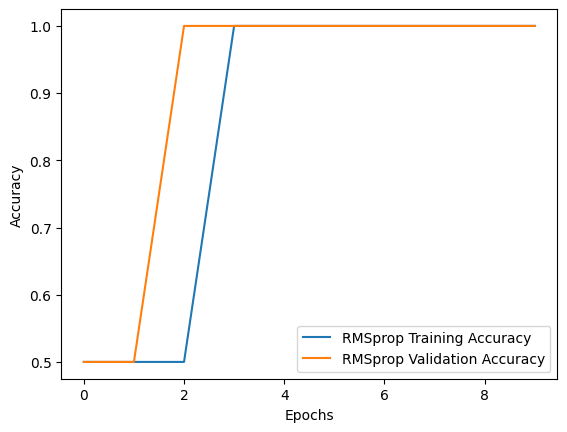

In [13]:
from tensorflow.keras.models import clone_model
import matplotlib.pyplot as plt

# Function to reset the model weights

def reset_model(model):
  # clone the model to reset the weights
  model_clone = clone_model(model)
  # model_clone.set_weights(model.get_weights())
  return model_clone

initial_model = reset_model(model)

# sgd model
sgd_model = reset_model(model)
sgd_model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
history_sgd = sgd_model.fit(train_generator, epochs=10, validation_data=validation_generator)

# Plot training and validation accuracy for sgd
plt.plot(history_sgd.history['accuracy'], label='SGD Training Accuracy')
plt.plot(history_sgd.history['val_accuracy'], label='SGD Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# RMSprop model
rmsprop_model = reset_model(model)
rmsprop_model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
history_rmsprop = rmsprop_model.fit(train_generator, epochs=10, validation_data=validation_generator)

# plot training and validation accuracy for RMSprop
plt.plot(history_rmsprop.history['accuracy'], label='RMSprop Training Accuracy')
plt.plot(history_rmsprop.history['val_accuracy'], label='RMSprop Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [16]:
# Load and preprocess the test data set

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    os.path.join(folder_path,'sample'),
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
)

test_loss, test_accuracy = model.evaluate(test_generator)
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
print(f'Test Loss: {test_loss:.4f}')

Found 20 images belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 1.0000 - loss: 1.2458e-32
Test Accuracy: 100.00%
Test Loss: 0.0000
